California housing data
https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, LassoCV, ElasticNetCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
import gc
import sys
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/California-housing")
RESULTS_DIR = PROJECT_DIR / "results"
FIG_DIR = PROJECT_DIR / "figures"

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

from src.tool import (
    evaluate_model
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Load the California housing data
cal = fetch_california_housing(as_frame=True)
X, y = cal.data, cal.target
feature_names = X.columns
print(feature_names)

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude'],
      dtype='object')


In [9]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# standardize
for col in X_train.columns:
    mean = X_train[col].mean()
    std = X_train[col].std()
    X_train[col] = (X_train[col] - mean) / std
    X_test[col] = (X_test[col] - mean) / std

,MedHouseVal
MedInc,0.688075
AveRooms,0.151948
HouseAge,0.105623
AveOccup,-0.023737
Population,-0.024650
Longitude,-0.045967
AveBedrms,-0.046701
Latitude,-0.144160


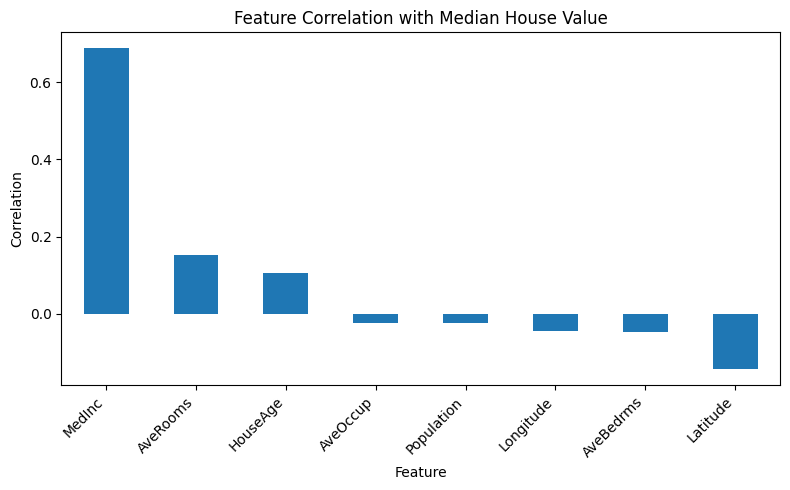

In [10]:
# Correlation with target
df = X.copy()
df["MedHouseVal"] = y

target_corr = (
    df.corr(numeric_only=True)["MedHouseVal"]
    .drop("MedHouseVal")
    .sort_values(ascending=False)
)

target_corr_df = pd.DataFrame({
    "Feature": target_corr.index,
    "Correlation": target_corr.values
})

display(target_corr)
target_corr_df.to_csv(RESULTS_DIR / "feature_target_correlation.csv", index=False)

target_corr.plot(kind="bar", figsize=(8,5))
plt.title("Feature Correlation with Median House Value")
plt.ylabel("Correlation")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_target_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

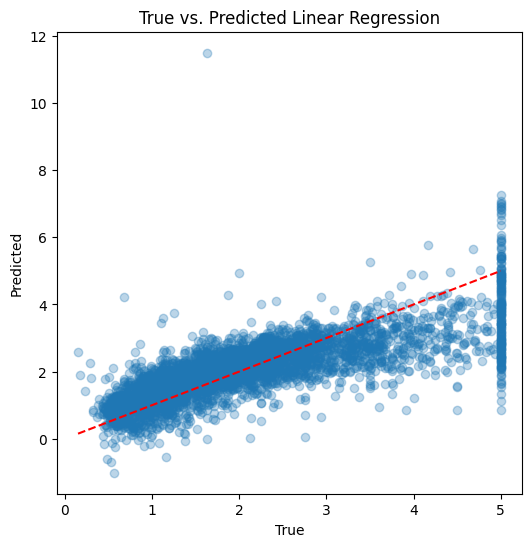

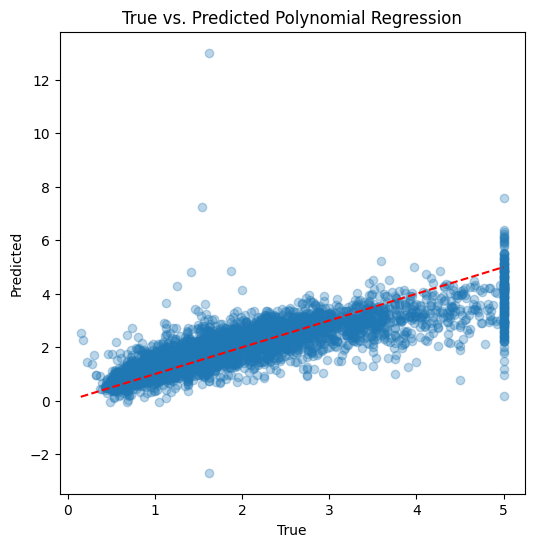

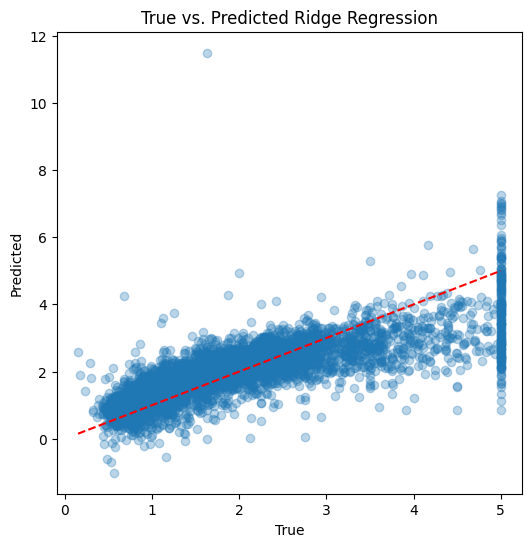

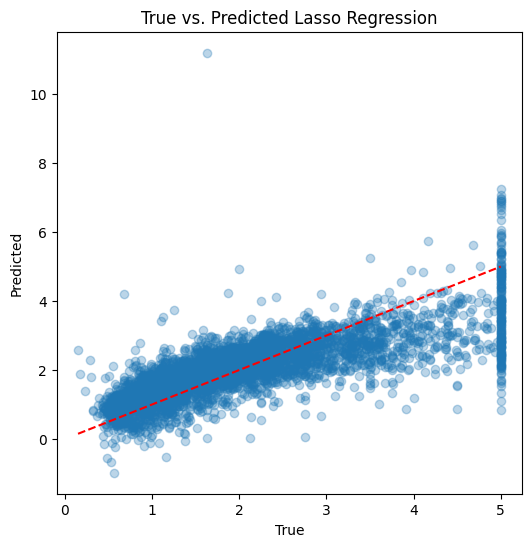

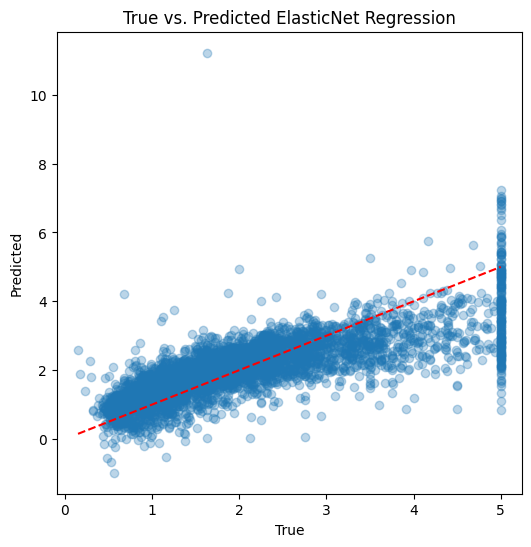

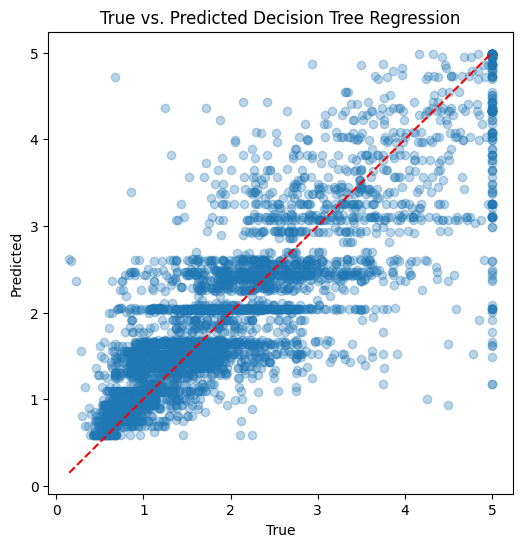

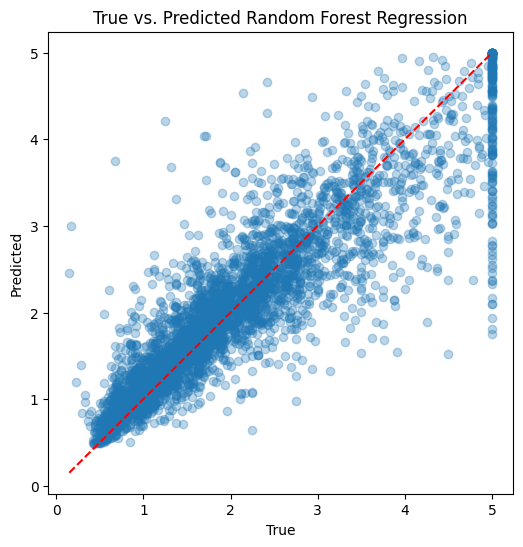

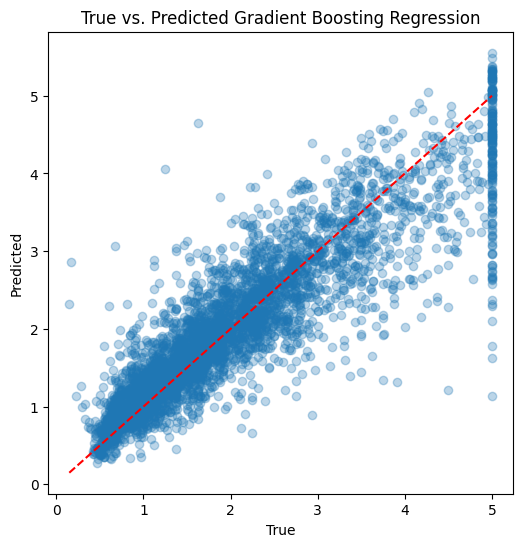

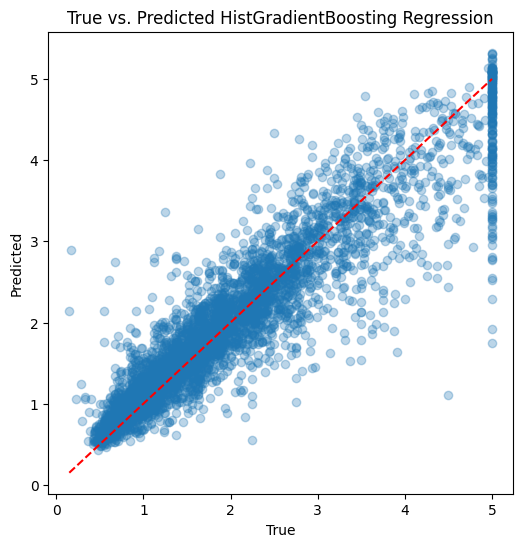

In [12]:
# regress the median house value for California districts on the eight predictor variables.
model_list = [
    ("Linear Regression", LinearRegression()),
    ("Polynomial Regression", make_pipeline(PolynomialFeatures(degree=2,include_bias=False), LinearRegression())),
    ("Ridge Regression", RidgeCV(
        alphas=[0.001, 0.01, 0.1, 1, 10, 100, 1000],
        scoring="r2",
        cv=10)),
    ("Lasso Regression", LassoCV(
        alphas=[0.001, 0.01, 0.1, 1, 10, 100, 1000],
        cv=10)),
    ("ElasticNet Regression", ElasticNetCV(
        alphas=[0.001, 0.01, 0.1, 1, 10, 100, 1000],
        l1_ratio=[0.1, 0.5, 0.9],
        cv=10,
        max_iter=10000)),
    ("Decision Tree Regression", DecisionTreeRegressor(
        max_depth=8,
        min_samples_leaf=20,
        random_state=42)),
    ("Random Forest Regression", RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1)),
    ("Gradient Boosting Regression", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42)),
    ("HistGradientBoosting Regression", HistGradientBoostingRegressor(
        learning_rate=0.05,
        max_iter=300,
        max_leaf_nodes=31,
        random_state=42))
]

results_path = RESULTS_DIR / "results.csv"
results_df = evaluate_model(model_list, X_train, y_train, X_test, y_test, results_path)

In [13]:
display(results_df)

,model,data,r^2,mae,mse,rmse
0,Linear Regression,Train,0.612551,0.528628,0.517933,0.719676
1,Linear Regression,Test,0.575788,0.533200,0.555892,0.745581
2,Polynomial Regression,Train,0.685268,0.460838,0.420727,0.648634
3,Polynomial Regression,Test,0.645682,0.467001,0.464302,0.681397
4,Ridge Regression,Train,0.612551,0.528624,0.517933,0.719676
5,Ridge Regression,Test,0.575816,0.533193,0.555855,0.745557
6,Lasso Regression,Train,0.612509,0.528703,0.517989,0.719715
7,Lasso Regression,Test,0.576856,0.533145,0.554491,0.744642
8,ElasticNet Regression,Train,0.612513,0.528689,0.517984,0.719711
9,ElasticNet Regression,Test,0.576794,0.533140,0.554573,0.744697
